# Data Analysis & Visualization

### Data Loading and Inspection

In [14]:
import zipfile
import pandas as pd
from io import TextIOWrapper
from Bio import SeqIO  

zip_path = "archive (23).zip"

with zipfile.ZipFile(zip_path, 'r') as z:

   
    print("Files inside ZIP:")
    for file in z.namelist():
        print(file)

    print("\n--- Reading TSV files ---\n")
    
    with z.open('cafa-6-protein-function-prediction - Copy/Train/train_terms.tsv') as f:
        train_terms = pd.read_csv(f, sep='\t')
        print("train_terms:")
        print(train_terms.head())
 
    with z.open('cafa-6-protein-function-prediction - Copy/Train/train_taxonomy.tsv') as f:
        train_taxonomy = pd.read_csv(f, sep='\t')
        print("\ntrain_taxonomy:")
        print(train_taxonomy.head())
 
    with z.open('cafa-6-protein-function-prediction - Copy/sample_submission.tsv') as f:
        sample_submission = pd.read_csv(f, sep='\t', on_bad_lines='skip')

    with z.open('cafa-6-protein-function-prediction - Copy/Train/train_sequences.fasta') as f:
        fasta_file = TextIOWrapper(f)
        sequences = list(SeqIO.parse(fasta_file, "fasta"))

        print("First 3 sequences:")
        for seq in sequences[:3]:
            print("ID:", seq.id)
            print("Sequence:", str(seq.seq)[:50], "...\n")

    with z.open('cafa-6-protein-function-prediction - Copy/Test/testsuperset.fasta') as f:
        fasta_file = TextIOWrapper(f)
        test_sequences = list(SeqIO.parse(fasta_file, "fasta"))

        print("First 3 test sequences:")
        for seq in test_sequences[:3]:
            print("ID:", seq.id)
            print("Sequence:", str(seq.seq)[:50], "...\n")

Files inside ZIP:
cafa-6-protein-function-prediction - Copy/IA.tsv
cafa-6-protein-function-prediction - Copy/Test/testsuperset-taxon-list.tsv
cafa-6-protein-function-prediction - Copy/Test/testsuperset.fasta
cafa-6-protein-function-prediction - Copy/Train/.ipynb_checkpoints/train_sequences-checkpoint.fasta
cafa-6-protein-function-prediction - Copy/Train/go-basic.obo
cafa-6-protein-function-prediction - Copy/Train/train_sequences.fasta
cafa-6-protein-function-prediction - Copy/Train/train_taxonomy.tsv
cafa-6-protein-function-prediction - Copy/Train/train_terms.tsv
cafa-6-protein-function-prediction - Copy/sample_submission.tsv

--- Reading TSV files ---

train_terms:
  EntryID        term aspect
0  Q5W0B1  GO:0000785      C
1  Q5W0B1  GO:0004842      F
2  Q5W0B1  GO:0051865      P
3  Q5W0B1  GO:0006275      P
4  Q5W0B1  GO:0006513      P

train_taxonomy:
  A0A0C5B5G6  9606
0     A0JNW5  9606
1     A0JP26  9606
2     A0PK11  9606
3     A1A4S6  9606
4     A1A519  9606
First 3 sequences:
I

### We convert the data into a DataFrame

In [13]:
seq_df = pd.DataFrame({
    "EntryID": [seq.id for seq in sequences],
    "sequence": [str(seq.seq) for seq in sequences],
    "seq_length": [len(seq.seq) for seq in sequences]
})

print("Sequences DataFrame:")
seq_df.head()

labels_df = train_terms.groupby('EntryID')['term'].apply(list).reset_index()

print("\nLabels DataFrame:")
labels_df.head()

final_df = pd.merge(seq_df, labels_df, on='EntryID', how='inner')

print("\nFinal DataFrame:")
final_df.head()

Sequences DataFrame:

Labels DataFrame:

Final DataFrame:


,EntryID,sequence,seq_length,term


### Protein length distribution

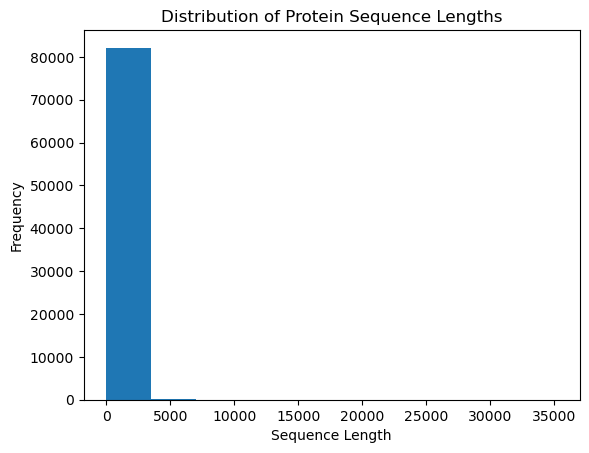

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


seq_lengths = [len(seq.seq) for seq in sequences]
plt.figure()
plt.hist(seq_lengths)
plt.title("Distribution of Protein Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

### Number of functions per protein

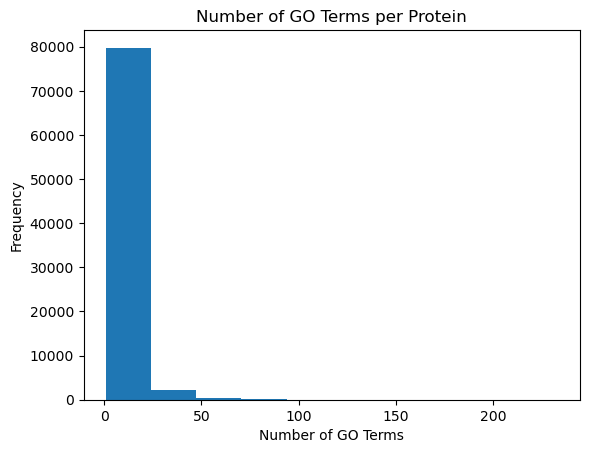

In [9]:
terms_per_protein = train_terms.groupby('EntryID').size()

plt.figure()
plt.hist(terms_per_protein)
plt.title("Number of GO Terms per Protein")
plt.xlabel("Number of GO Terms")
plt.ylabel("Frequency")
plt.show()

### Most Frequently Used GO Terms

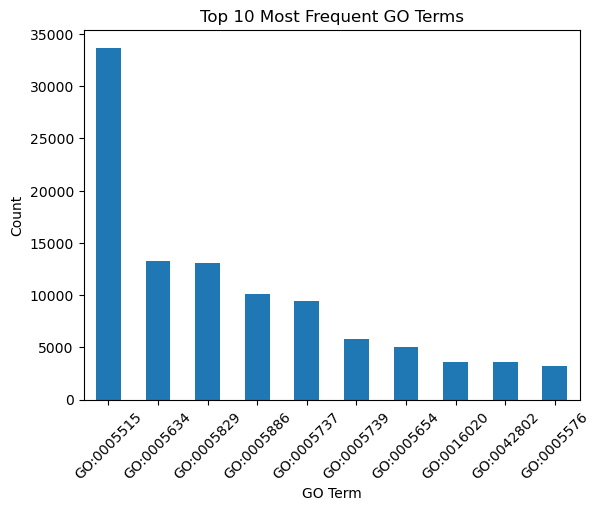

In [10]:
top_terms = train_terms['term'].value_counts().head(10)

plt.figure()
top_terms.plot(kind='bar')
plt.title("Top 10 Most Frequent GO Terms")
plt.xlabel("GO Term")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Preprocessing

In [17]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer


seq_df.dropna(inplace=True)

# 3. Feature Engineering 
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")


def amino_acid_features(sequence):
    features = {}
    length = len(sequence)

    for aa in amino_acids:
        features[f"freq_{aa}"] = sequence.count(aa) / length

    features["seq_length"] = length
    return features


features_df = seq_df["sequence"].apply(amino_acid_features)
features_df = pd.DataFrame(features_df.tolist())

features_df["EntryID"] = seq_df["EntryID"]

# 4. معالجة labels (Multi-label)
labels_df = train_terms.groupby('EntryID')['term'].apply(list).reset_index()

# تحويل labels إلى binary matrix
mlb = MultiLabelBinarizer()
labels_encoded = mlb.fit_transform(labels_df['term'])

labels_encoded_df = pd.DataFrame(labels_encoded, columns=mlb.classes_)
labels_encoded_df["EntryID"] = labels_df["EntryID"]

# 5. دمج Features + Labels
final_df = pd.merge(features_df, labels_encoded_df, on='EntryID', how='inner')

X = final_df.drop(columns=["EntryID"])
Y = final_df[mlb.classes_]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (0, 26146)
Y shape: (0, 26125)
